<a href="https://colab.research.google.com/github/kumarabhishek-crypto/2520030448_Machine-Learning/blob/main/Titanic_2520030448.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# Load the file you uploaded to Colab
df = pd.read_csv('Titanic-Dataset.csv')

print("=== STEP 1: DEFINE THE PROBLEM ===")
print("Task: Supervised Binary Classification (Predict 'Survived': 0 = No, 1 = Yes)")

print("\n=== STEP 2: UNDERSTAND THE DATA ===")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

print("--- First 5 Rows ---")
display(df.head())

print("\n--- Summary Statistics ---")
display(df.describe())

=== STEP 1: DEFINE THE PROBLEM ===
Task: Supervised Binary Classification (Predict 'Survived': 0 = No, 1 = Yes)

=== STEP 2: UNDERSTAND THE DATA ===
Shape: 891 rows, 12 columns

--- First 5 Rows ---


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



--- Summary Statistics ---


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [2]:
print("=== STEP 3: CLEAN THE DATA (Audit) ===")

# Check for missing values
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_percent})

print("--- Missing Values Report ---")
display(missing_df[missing_df['Missing Count'] > 0])

print(f"\n--- Total Duplicate Rows: {df.duplicated().sum()} ---")

=== STEP 3: CLEAN THE DATA (Audit) ===
--- Missing Values Report ---


,Missing Count,Percentage (%)
Age,177,19.865320
Cabin,687,77.104377
Embarked,2,0.224467



--- Total Duplicate Rows: 0 ---


=== STEP 4: EXPLORATORY DATA ANALYSIS (EDA) ===


/tmp/ipykernel_488/2945031413.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0, 0], palette='Set2', errorbar=None)
/tmp/ipykernel_488/2945031413.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[0, 1], palette='Set1', errorbar=None)


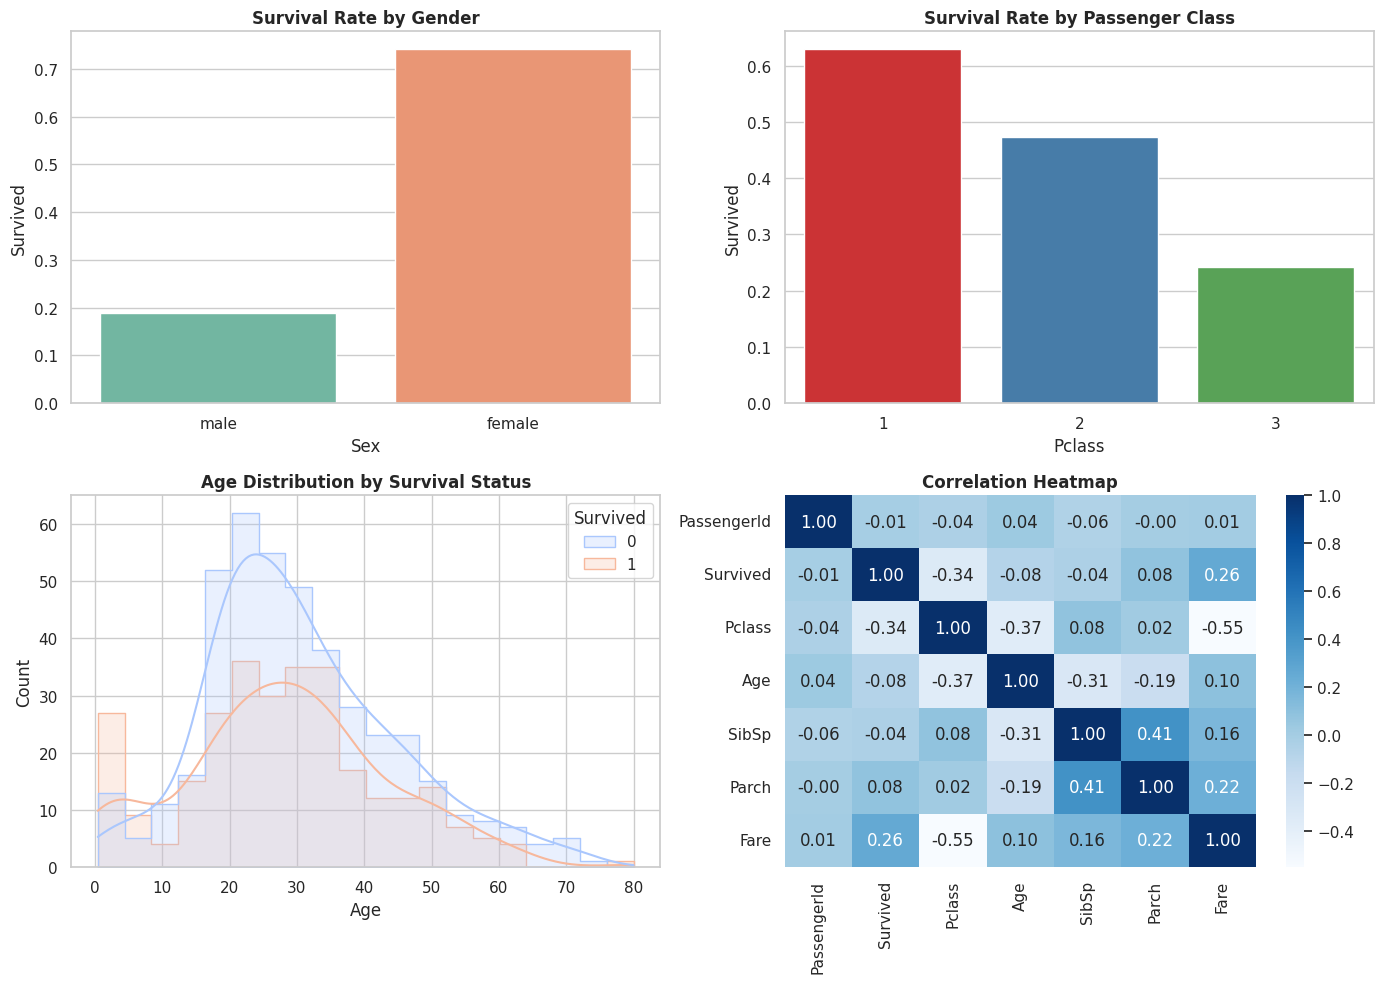

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

print("=== STEP 4: EXPLORATORY DATA ANALYSIS (EDA) ===")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Survival Rate by Gender
sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0, 0], palette='Set2', errorbar=None)
axes[0, 0].set_title('Survival Rate by Gender', fontsize=12, fontweight='bold')

# 2. Survival Rate by Passenger Class
sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[0, 1], palette='Set1', errorbar=None)
axes[0, 1].set_title('Survival Rate by Passenger Class', fontsize=12, fontweight='bold')

# 3. Age Distribution by Survival
sns.histplot(data=df, x='Age', hue='Survived', kde=True, ax=axes[1, 0], palette='coolwarm', element='step')
axes[1, 0].set_title('Age Distribution by Survival Status', fontsize=12, fontweight='bold')

# 4. Feature Correlation Matrix
numeric_cols = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='Blues', fmt='.2f', ax=axes[1, 1])
axes[1, 1].set_title('Correlation Heatmap', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [4]:
print("=== STEP 5: PREPROCESSING & FEATURE ENGINEERING ===")

df_clean = df.copy()

# 1. Impute Missing Values
# Impute Age based on Class and Gender median
df_clean['Age'] = df_clean.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
# Impute Embarked with the most common port (mode)
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

# 2. Feature Engineering
df_clean['Has_Cabin'] = df_clean['Cabin'].notnull().astype(int)
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1
df_clean['IsAlone'] = (df_clean['FamilySize'] == 1).astype(int)

# Extract Titles from Name
df_clean['Title'] = df_clean['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df_clean['Title'] = df_clean['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df_clean['Title'] = df_clean['Title'].replace(['Mlle', 'Ms'], 'Miss')
df_clean['Title'] = df_clean['Title'].replace('Mme', 'Mrs')

# 3. Drop unneeded raw identifier columns
df_clean = df_clean.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

print("Data Cleaning Complete!")
print("Remaining Missing Values:", df_clean.isnull().sum().sum())
display(df_clean.head())

=== STEP 5: PREPROCESSING & FEATURE ENGINEERING ===
Data Cleaning Complete!
Remaining Missing Values: 0


<>:17: SyntaxWarning: invalid escape sequence '\.'
<>:17: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_488/273064388.py:17: SyntaxWarning: invalid escape sequence '\.'
  df_clean['Title'] = df_clean['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Has_Cabin,FamilySize,IsAlone,Title
0,0,3,male,22.0,1,0,7.2500,S,0,2,0,Mr
1,1,1,female,38.0,1,0,71.2833,C,1,2,0,Mrs
2,1,3,female,26.0,0,0,7.9250,S,0,1,1,Miss
3,1,1,female,35.0,1,0,53.1000,S,1,2,0,Mrs
4,0,3,male,35.0,0,0,8.0500,S,0,1,1,Mr


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("=== STEP 6: ENCODING & MODEL TRAINING ===")

# 1. One-Hot Encode categorical variables (Sex, Embarked, Title)
df_model = pd.get_dummies(df_clean, columns=['Sex', 'Embarked', 'Title'], drop_first=True)

# 2. Separate Features (X) and Target (y)
X = df_model.drop(columns=['Survived'])
y = df_model['Survived']

# 3. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Train a Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Predictions & Evaluation
y_pred = model.predict(X_test)

print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

=== STEP 6: ENCODING & MODEL TRAINING ===
Model Accuracy: 79.89%

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       110
           1       0.74      0.74      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

